# Figure: Effects of Supervision

This notebook reproduces "Figure 4: **Results: Supervision**" from the manuscript.

In [1]:
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import numpy as np
import pandas as pd
sys.path.append("..")

from experiments.config import experiments
from src.utils import to_list_of_dicts

In [2]:
import matplotlib as mpl

mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams["axes.labelsize"] = 16
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['axes.titlesize'] = 17
mpl.rcParams['text.usetex'] = True
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [3]:
def load_result(i, save_dir):
    fp = os.path.join(save_dir, f'{i:03d}.json')
    if os.path.exists(fp):
        with open(fp, "r") as f:
            return json.load(f)['metrics']
    else:
        return None

## Condition Number 5

In [4]:
lams = [0.0, 3e-5, 1e-4, 3e-4, 1e-3]
lr_model = 1e-5
lr_unmix = 1e-3

titles = {
    "train_unsup": "Train Loss (Unmixing)",
    "train_sup": "Train Loss (Supervised)",
    "train_accuracy_task_0": "Train Task 0",
    "train_accuracy_task_1": "Train Task 1",
    "train_accuracy_task_2": "Train Task 2",
    "test_unsup": "Test Loss (Unmixing)",
    "test_sup": "Test Loss (Supervised)",
    "test_accuracy_task_0": "Test Task 0",
    "test_accuracy_task_1": "Test Task 1",
    "test_accuracy_task_2": "Train Task 2",
    "amari_distance": "Amari Distance"
}

def create_ax(ax, df, save_dir, measure, lam, lr_unmix, label, optim="adam", sup_color="tab:blue", base_color="k", limit=1):
    if lam == 0.0:
        df1 = df[(df['lam']==lam) & (df['lr_unmix']==lr_unmix)]
        performance = []
        count = 0
        for c, row in df1.iterrows():
            result = load_result(row["index"], save_dir)
            count += 1
            if not (result is None):
                performance.append(result[measure])
                x_ = result["iterations"]
        if len(df1) > 0:
            if len(performance) > 0:
                performance = np.stack(performance)
                # performance = performance / performance[:, 0].reshape(-1, 1)
                ax.plot(x_[limit:], performance.mean(axis=0)[limit:], color=base_color, label=f"Baseline Mean ({label})")
                ax.plot(x_[limit:], np.quantile(performance, 0.5, axis=0)[limit:], color=base_color, linestyle="dashed", label=f"Baseline Median ({label})")
                for line in performance:
                    ax.plot(x_[limit:], line[limit:], alpha=0.1, color=base_color, linewidth=1)
    else:
        df1 = df[(df['lam']==lam) & (df['lr_model']==lr_model) & (df["optim"] == optim) & (df['lr_unmix']==lr_unmix)]
        performance = []
        count = 0
        for _, row in df1.iterrows():
            result = load_result(row["index"], save_dir)
            count += 1
            if not (result is None):
                performance.append(result[measure])
                x_ = result["iterations"]
        if len(df1) > 0:
            if len(performance) > 0:
                performance = np.stack(performance)
                # performance = performance / performance[:, 0].reshape(-1, 1)
                ax.plot(x_[limit:], performance.mean(axis=0)[limit:], color=sup_color, label=f"Supervised Mean ({label})")
                ax.plot(x_[limit:], np.quantile(performance, 0.5, axis=0)[limit:], color=sup_color, linestyle="dashed", label=f"Supervised Median ({label})")
                for line in performance:
                    ax.plot(x_[limit:], line[limit:], alpha=0.2, color=sup_color, linewidth=1)

    ax.patch.set_edgecolor('black')
    ax.patch.set_linewidth(1.5)

def join_handles_and_labels(axes):
    all_labels = set()
    pairs = []
    for ax in axes.flatten():
        handles, labels = ax.get_legend_handles_labels()
        for h, l in zip(handles, labels):
            if not (l in all_labels):
                all_labels.add(l)
                pairs.append((h, l))
    handles, labels = [], []
    for (h, l) in pairs:
        handles.append(h)
        labels.append(l)
    return handles, labels

We load the results from all experiments, including trajectories from misspecified hyperparameters (i.e., optimization failures). We then subset to particular hyperparmaeters to generate the figures.

In [5]:
experiment = "multitarget_simulated_cond_5"

save_dir1 = f"../experiments/out/{experiment}"
lst_ = to_list_of_dicts(experiments[experiment])
    
metrics = []
lst = []
opt_errors = 0
time_errors = 0
for i in range(len(lst_)):
    try:
        result = load_result(i, save_dir1)
        if result is None:
            opt_errors += 1
        else:
            metrics.append(load_result(i, save_dir1))
            lst.append(lst_[i])
    except FileNotFoundError:
        print(f"\t TIMED OUT: {i}")
        print(lst_[i])
        time_errors += 1

print(f"Optimization errors {opt_errors}")
print(f"Time errors {time_errors}")
# df = pd.DataFrame(lst).reset_index()
df1 = pd.DataFrame(lst_).reset_index()
df1 = df1.fillna(0.0)
df1

Optimization errors 410
Time errors 0


,index,lr_unmix,lr_model,lam,seed,density,optim,cond_number
0,0,0.0001,0.000001,0.000,0,huber,sgd,5
1,1,0.0001,0.000001,0.000,0,huber,adam,5
2,2,0.0001,0.000001,0.000,1,huber,sgd,5
3,3,0.0001,0.000001,0.000,1,huber,adam,5
4,4,0.0001,0.000001,0.000,2,huber,sgd,5
...,...,...,...,...,...,...,...,...
955,955,0.0010,0.000010,0.003,17,huber,adam,5
956,956,0.0010,0.000010,0.003,18,huber,sgd,5
957,957,0.0010,0.000010,0.003,18,huber,adam,5
958,958,0.0010,0.000010,0.003,19,huber,sgd,5


In [6]:
experiment = "multitarget_simulated_cond_7"

save_dir2 = f"../experiments/out/{experiment}"
lst_ = to_list_of_dicts(experiments[experiment])
    
metrics = []
lst = []
opt_errors = 0
time_errors = 0
for i in range(len(lst_)):
    try:
        result = load_result(i, save_dir2)
        if result is None:
            opt_errors += 1
        else:
            metrics.append(load_result(i, save_dir2))
            lst.append(lst_[i])
    except FileNotFoundError:
        print(f"\t TIMED OUT: {i}")
        print(lst_[i])
        time_errors += 1

print(f"Optimization errors {opt_errors}")
print(f"Time errors {time_errors}")
# df = pd.DataFrame(lst).reset_index()
df2 = pd.DataFrame(lst_).reset_index()
df2 = df2.fillna(0.0)
df2

Optimization errors 410
Time errors 0


,index,lr_unmix,lr_model,lam,seed,density,optim,cond_number
0,0,0.0001,0.000001,0.000,0,huber,sgd,5
1,1,0.0001,0.000001,0.000,0,huber,adam,5
2,2,0.0001,0.000001,0.000,1,huber,sgd,5
3,3,0.0001,0.000001,0.000,1,huber,adam,5
4,4,0.0001,0.000001,0.000,2,huber,sgd,5
...,...,...,...,...,...,...,...,...
955,955,0.0010,0.000010,0.003,17,huber,adam,5
956,956,0.0010,0.000010,0.003,18,huber,sgd,5
957,957,0.0010,0.000010,0.003,18,huber,adam,5
958,958,0.0010,0.000010,0.003,19,huber,sgd,5


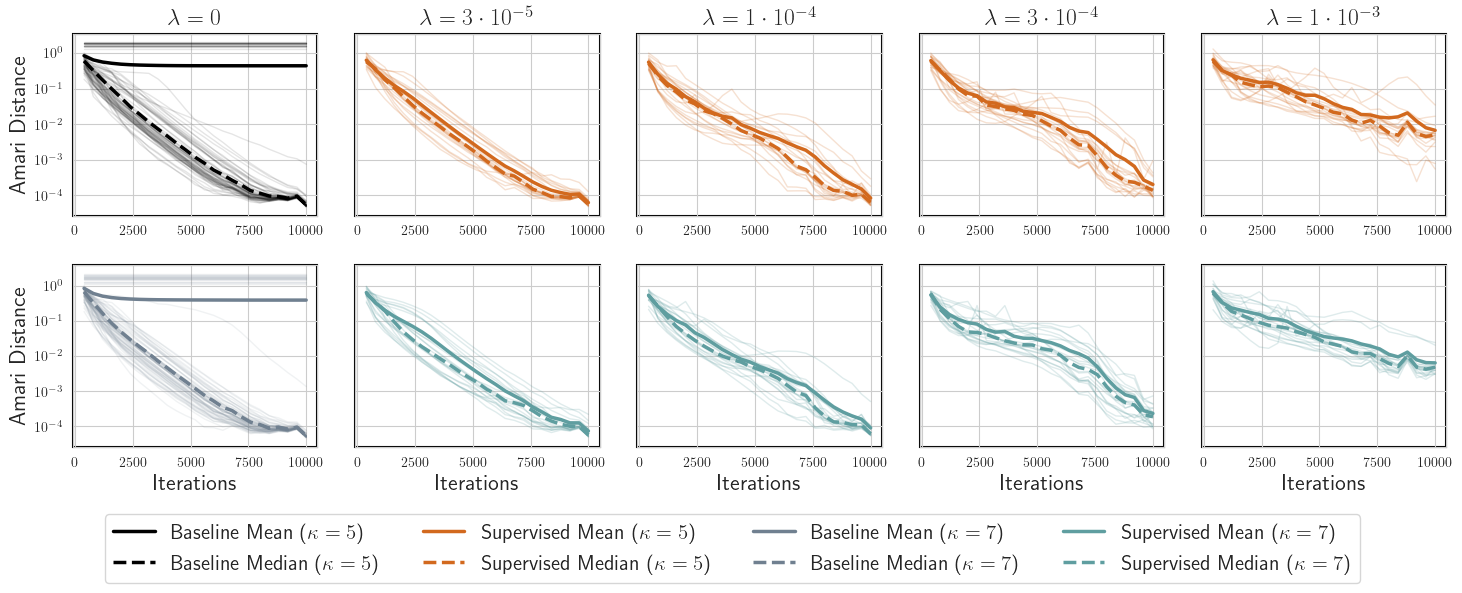

In [7]:
sns.set_style("whitegrid")

scale = 3
optim = "adam"

fig, axes = plt.subplots(2, len(lams), figsize=(len(lams) * scale, 1.8 * scale), sharey="row")

titles = {
    0.0:  r"$\lambda = 0$",
    3e-5: r"$\lambda = 3 \cdot 10^{-5}$",
    1e-4: r"$\lambda = 1 \cdot 10^{-4}$",
    3e-4: r"$\lambda = 3 \cdot 10^{-4}$",
    1e-3: r"$\lambda = 1 \cdot 10^{-3}$",
}

for i, lam in enumerate(lams):  
    axes[0, i].set_yscale("log")
    axes[0, i].set_title(titles[lam])
    create_ax(axes[0, i], df1, save_dir1, "amari_distance", lam, lr_unmix, r"$\kappa = 5$", sup_color="chocolate", base_color="k")

    axes[1, i].set_yscale("log")
    axes[1, i].set_xlabel("Iterations")
    create_ax(axes[1, i], df2, save_dir2, "amari_distance", lam, lr_unmix, r"$\kappa = 7$", sup_color="cadetblue", base_color="slategray")

axes[0, 0].set_ylabel("Amari Distance")
axes[1, 0].set_ylabel("Amari Distance")

handles, labels = join_handles_and_labels(axes)
fig.legend(handles=handles, labels=labels, loc='center', bbox_to_anchor=(0.5, -0.05), ncol=4)
fig.tight_layout(pad=2)
plt.savefig("../figures/nonconvex_trajectory.pdf", bbox_inches="tight")
plt.show()